# Part 1: 
--------------------------------------------------------------------

##### Raw hospital CT scans (.nii files) 
         ↓
##### Loaded as 3D numpy arrays
         ↓
##### Understood the coordinate system (axial/coronal/sagittal)
         ↓
##### Applied medical preprocessing (HU windowing)
         ↓
##### Visualized anatomy + ground truth masks
         ↓
##### Identified the key challenges:
- class imbalance (tumour < 1% of voxels)
- variable volume sizes
- variable voxel spacing

--------------------------------------------------------------------

In [1]:
import os

LIVER_PATH = '/kaggle/input/datasets/andrewmvd/liver-tumor-segmentation'

# See all folders
for item in sorted(os.listdir(LIVER_PATH)):
    print(item)

segmentations
volume_pt1
volume_pt2
volume_pt3
volume_pt4
volume_pt5


In [2]:
# Count volumes and segmentations
for root, dirs, files in os.walk(LIVER_PATH):
    nii_files = [f for f in files if f.endswith('.nii')]
    if nii_files:
        print(f"{root}: {len(nii_files)} files")
        print(f"  Example: {nii_files[0]}")

/kaggle/input/datasets/andrewmvd/liver-tumor-segmentation/volume_pt3: 10 files
  Example: volume-26.nii
/kaggle/input/datasets/andrewmvd/liver-tumor-segmentation/volume_pt2: 10 files
  Example: volume-12.nii
/kaggle/input/datasets/andrewmvd/liver-tumor-segmentation/volume_pt1: 11 files
  Example: volume-3.nii
/kaggle/input/datasets/andrewmvd/liver-tumor-segmentation/segmentations: 131 files
  Example: segmentation-100.nii
/kaggle/input/datasets/andrewmvd/liver-tumor-segmentation/volume_pt5: 10 files
  Example: volume-47.nii
/kaggle/input/datasets/andrewmvd/liver-tumor-segmentation/volume_pt4: 10 files
  Example: volume-34.nii


In [3]:
#setup & path mapping

import os
import json
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

LIVER_PATH = '/kaggle/input/datasets/andrewmvd/liver-tumor-segmentation'
SEG_PATH   = os.path.join(LIVER_PATH, 'segmentations')

# Collect all volume files across all pt folders
volume_files = {}
for folder in sorted(os.listdir(LIVER_PATH)):
    if folder.startswith('volume_pt'):
        folder_path = os.path.join(LIVER_PATH, folder)
        for f in os.listdir(folder_path):
            if f.endswith('.nii'):
                idx = f.replace('volume-', '').replace('.nii', '')
                volume_files[idx] = os.path.join(folder_path, f)

# Collect segmentation files
seg_files = {}
for f in os.listdir(SEG_PATH):
    if f.endswith('.nii'):
        idx = f.replace('segmentation-', '').replace('.nii', '')
        seg_files[idx] = os.path.join(SEG_PATH, f)

# Find matched pairs (volume + segmentation both exist)
common_ids = sorted(set(volume_files.keys()) & set(seg_files.keys()), key=int)

print(f"Total volumes found:       {len(volume_files)}")
print(f"Total segmentations found: {len(seg_files)}")
print(f"Matched pairs:             {len(common_ids)}")
print(f"Sample IDs: {common_ids[:5]}")

Total volumes found:       51
Total segmentations found: 131
Matched pairs:             51
Sample IDs: ['0', '1', '2', '3', '4']


In [4]:
# load the first matched pair
sample_id = common_ids[0]
print(f"Loading case: volume-{sample_id}")

img_nib = nib.load(volume_files[sample_id])
lbl_nib = nib.load(seg_files[sample_id])

img_data = img_nib.get_fdata()
lbl_data = lbl_nib.get_fdata()

print(f"\nImage shape:    {img_data.shape}  (H x W x Depth)")
print(f"Label shape:    {lbl_data.shape}")
print(f"Voxel spacing:  {img_nib.header.get_zooms()} mm")
print(f"\nIntensity min:  {img_data.min():.1f} HU")
print(f"Intensity max:  {img_data.max():.1f} HU")
print(f"Intensity mean: {img_data.mean():.1f} HU")
print(f"Intensity std:  {img_data.std():.1f} HU")

print(f"\nUnique label values: {np.unique(lbl_data)}")
total_voxels = lbl_data.size
print(f"Background voxels: {int(np.sum(lbl_data==0)):>12,}  ({100*np.mean(lbl_data==0):.1f}%)")
print(f"Liver voxels:      {int(np.sum(lbl_data==1)):>12,}  ({100*np.mean(lbl_data==1):.1f}%)")
print(f"Tumour voxels:     {int(np.sum(lbl_data==2)):>12,}  ({100*np.mean(lbl_data==2):.1f}%)")

Loading case: volume-0

Image shape:    (512, 512, 75)  (H x W x Depth)
Label shape:    (512, 512, 75)
Voxel spacing:  (np.float32(0.703125), np.float32(0.703125), np.float32(5.0)) mm

Intensity min:  -3024.0 HU
Intensity max:  1410.0 HU
Intensity mean: -948.9 HU
Intensity std:  1160.8 HU

Unique label values: [0. 1. 2.]
Background voxels:   19,108,173  (97.2%)
Liver voxels:           550,036  (2.8%)
Tumour voxels:            2,591  (0.0%)


In [5]:
#CT windowing function

def window_ct(volume, wl=50, ww=400):
    """
    Apply CT windowing for soft tissue visibility.
    WL=50, WW=400 is the standard soft tissue window for liver.
    Raw CT values (HU) range -1000 to +3000 — liver is invisible without this.
    """
    low  = wl - ww // 2   # -150
    high = wl + ww // 2   #  250
    windowed = np.clip(volume, low, high)
    # Normalize to [0, 1] for display
    windowed = (windowed - low) / (high - low)
    return windowed

img_windowed = window_ct(img_data)
print(f"After windowing — min: {img_windowed.min():.2f}, max: {img_windowed.max():.2f}")

After windowing — min: 0.00, max: 1.00


Best axial slice:   58  (tumour voxels: 538)
Best coronal slice: 186
Best sagittal slice:187


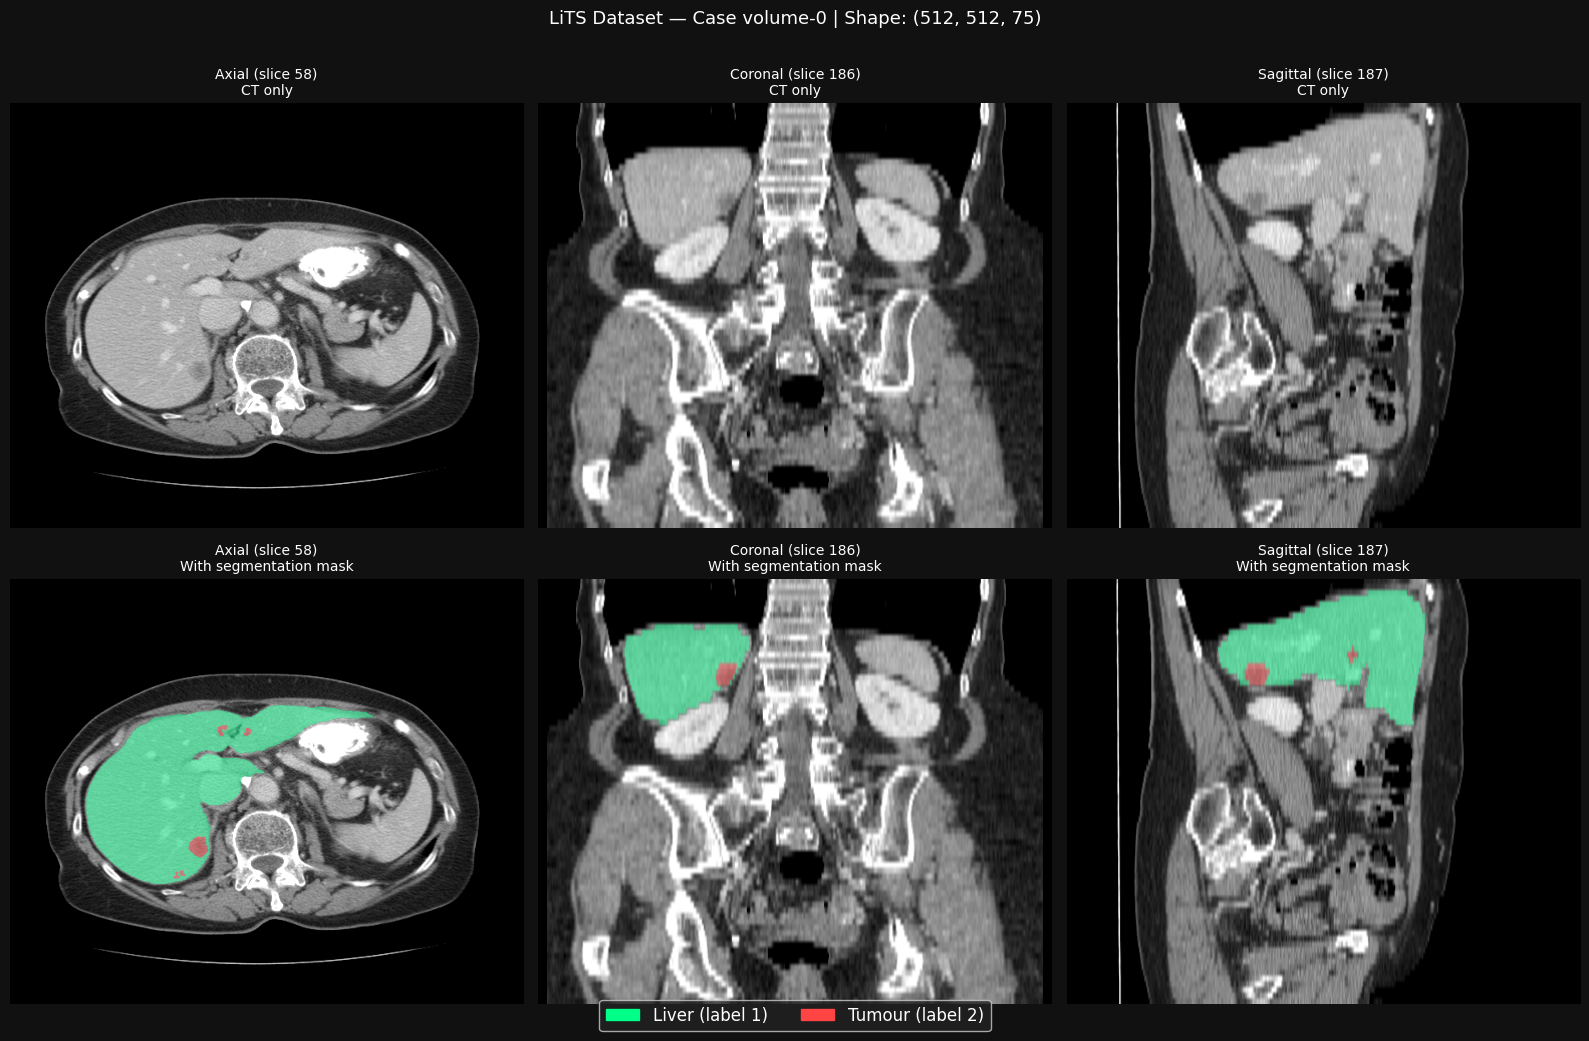

slice_visualization.png


In [6]:
#visualized 3 orthogonal slices with mask overlay

# find a good slice that actually contains liver/tumour
# (center slice often misses small tumours)
def find_best_slice(label, axis=2):
    """Find the slice along given axis with most tumour voxels."""
    tumour_counts = np.sum(label == 2, axis=tuple(i for i in range(3) if i != axis))
    best = np.argmax(tumour_counts)
    return best if tumour_counts[best] > 0 else label.shape[axis] // 2

ax_idx  = find_best_slice(lbl_data, axis=2)
cor_idx = find_best_slice(lbl_data, axis=1)
sag_idx = find_best_slice(lbl_data, axis=0)

print(f"Best axial slice:   {ax_idx}  (tumour voxels: {int(np.sum(lbl_data[:,:,ax_idx]==2))})")
print(f"Best coronal slice: {cor_idx}")
print(f"Best sagittal slice:{sag_idx}")

# label colormap: transparent bg, green liver, red tumour
label_cmap = ListedColormap(['none', '#00ff88', '#ff4444'])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#111111')
for ax in axes.flatten():
    ax.set_facecolor('#111111')

views = [
    (img_windowed[:, :, ax_idx],  lbl_data[:, :, ax_idx],  f'Axial (slice {ax_idx})'),
    (img_windowed[:, cor_idx, :], lbl_data[:, cor_idx, :], f'Coronal (slice {cor_idx})'),
    (img_windowed[sag_idx, :, :], lbl_data[sag_idx, :, :], f'Sagittal (slice {sag_idx})'),
]

for col, (img_slice, lbl_slice, title) in enumerate(views):
    # Row 1: CT only
    axes[0, col].imshow(img_slice.T, cmap='gray', origin='lower', aspect='auto')
    axes[0, col].set_title(f'{title}\nCT only', color='white', fontsize=10, pad=6)
    axes[0, col].axis('off')

    # row 2: CT + label overlay
    axes[1, col].imshow(img_slice.T, cmap='gray', origin='lower', aspect='auto')
    axes[1, col].imshow(lbl_slice.T, cmap=label_cmap,
                        vmin=0, vmax=2, alpha=0.45, origin='lower', aspect='auto')
    axes[1, col].set_title(f'{title}\nWith segmentation mask', color='white', fontsize=10, pad=6)
    axes[1, col].axis('off')

liver_patch  = mpatches.Patch(color='#00ff88', label='Liver (label 1)')
tumour_patch = mpatches.Patch(color='#ff4444', label='Tumour (label 2)')
fig.legend(handles=[liver_patch, tumour_patch],
           loc='lower center', ncol=2,
           facecolor='#222222', labelcolor='white', fontsize=12,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle(f'LiTS Dataset — Case volume-{sample_id} | Shape: {img_data.shape}',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('slice_visualization.png', bbox_inches='tight',
            facecolor='#111111', dpi=150)
plt.show()
print("slice_visualization.png")

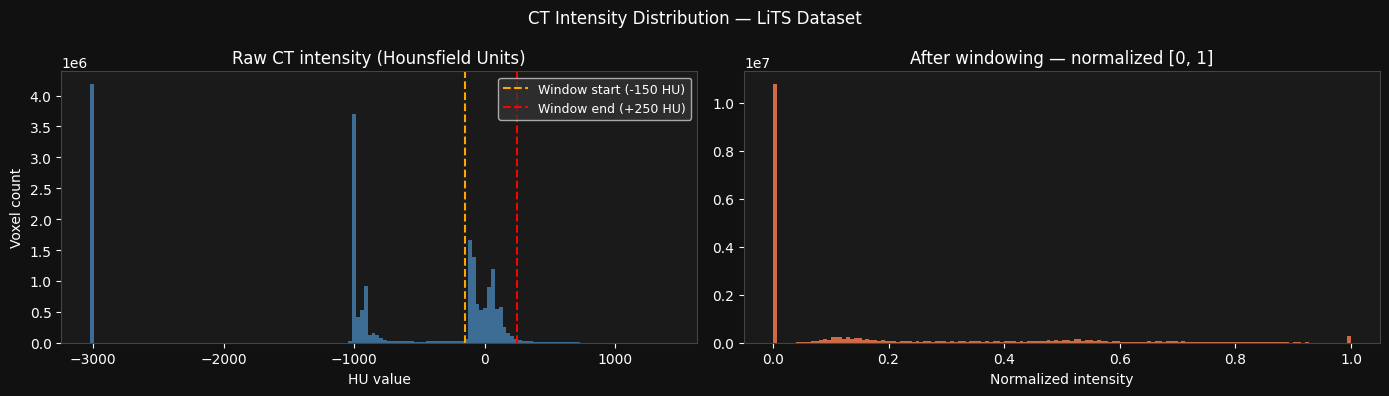

intensity_histogram.png


In [7]:
#intensity histogram

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#111111')
for ax in axes:
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

# Raw
axes[0].hist(img_data.flatten(), bins=150, color='steelblue', alpha=0.8)
axes[0].axvline(x=-150, color='orange', linestyle='--', linewidth=1.5, label='Window start (-150 HU)')
axes[0].axvline(x=250,  color='red',    linestyle='--', linewidth=1.5, label='Window end (+250 HU)')
axes[0].set_title('Raw CT intensity (Hounsfield Units)')
axes[0].set_xlabel('HU value')
axes[0].set_ylabel('Voxel count')
axes[0].legend(facecolor='#333333', labelcolor='white', fontsize=9)

# Windowed
axes[1].hist(img_windowed.flatten(), bins=150, color='coral', alpha=0.8)
axes[1].set_title('After windowing — normalized [0, 1]')
axes[1].set_xlabel('Normalized intensity')

plt.suptitle('CT Intensity Distribution — LiTS Dataset', color='white', fontsize=12)
plt.tight_layout()
plt.savefig('intensity_histogram.png', bbox_inches='tight',
            facecolor='#111111', dpi=150)
plt.show()
print("intensity_histogram.png")

In [8]:
#quick stats across 5 cases

print(f"{'Case':<12} {'Shape':<22} {'Spacing (mm)':<22} {'Liver %':>8} {'Tumour %':>10}")
print("─" * 78)

for cid in common_ids[:5]:
    img = nib.load(volume_files[cid]).get_fdata()
    lbl = nib.load(seg_files[cid]).get_fdata()
    spacing = nib.load(volume_files[cid]).header.get_zooms()
    spacing_str = f"{spacing[0]:.2f}x{spacing[1]:.2f}x{spacing[2]:.2f}"
    liver_pct  = 100 * np.mean(lbl == 1)
    tumour_pct = 100 * np.mean(lbl == 2)
    print(f"volume-{cid:<5} {str(img.shape):<22} {spacing_str:<22} {liver_pct:>7.2f}% {tumour_pct:>9.3f}%")

print("\n tumour % is very small — this is normal for LiTS (class imbalance challenge)")

Case         Shape                  Spacing (mm)            Liver %   Tumour %
──────────────────────────────────────────────────────────────────────────────
volume-0     (512, 512, 75)         0.70x0.70x5.00            2.80%     0.013%
volume-1     (512, 512, 123)        0.68x0.68x5.00            2.00%     0.022%
volume-2     (512, 512, 517)        0.78x0.78x1.00            2.35%     0.010%
volume-3     (512, 512, 534)        0.69x0.69x1.00            2.32%     0.002%
volume-4     (512, 512, 841)        0.90x0.90x0.80            1.50%     0.688%

 tumour % is very small — this is normal for LiTS (class imbalance challenge)


## data exploration

**dataset:** LiTS (Liver Tumor Segmentation Challenge)
- 131 CT volumes with pixel-level segmentation masks
- Labels: 0 = background, 1 = liver, 2 = tumour
- Format: NIfTI (.nii), 3D volumes ~512×512×variable slices

**key findings:**
- CT intensities range roughly -1000 to +2000 HU (Hounsfield Units)
- Soft tissue windowing (WL=50, WW=400) essential for liver visibility
- Severe class imbalance: tumour voxels < 1% of total — 
  this motivates using Dice loss over cross-entropy in training
- Voxel spacing varies per case — resampling needed before training

--> next step: build U-Net architecture with MONAI 

-------------------------------------------------
# Step 2
##### Input: 3D CT volume (1 channel)
    ↓
##### Encoder: shrinks spatial size, learns "what is this region?"
    ↓
##### Bottleneck: most compressed representation
    ↓
##### Decoder: grows back to original size, learns "where exactly?"
    ↓
##### Output: 3D segmentation map (3 channels: background / liver / tumour)

-------------------------------------------------

In [9]:
#step 2
!pip install monai --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 71.2 MB/s eta 0:00:00


In [10]:
import os
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,      # ← replaces AddChanneld
    ScaleIntensityRanged,
    CropForegroundd,
    RandCropByPosNegLabeld,
    RandFlipd,
    RandRotate90d,
    ToTensord,
    EnsureTyped,              # ← replaces ToTensord in newer MONAI
)
from monai.data import CacheDataset, list_data_collate
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric

# Check MONAI version so we know exactly what we're working with
import monai
print(f"MONAI version:   {monai.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"VRAM:            {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-28 12:13:34.855957: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777378415.094166      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777378415.160973      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777378415.703408      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777378415.703481      24 computation_placer.cc:1

MONAI version:   1.5.2
PyTorch version: 2.10.0+cu128
CUDA available:  True
GPU:             Tesla T4
VRAM:            15.6 GB


In [11]:
LIVER_PATH = '/kaggle/input/datasets/andrewmvd/liver-tumor-segmentation'
SEG_PATH   = os.path.join(LIVER_PATH, 'segmentations')

volume_files = {}
for folder in sorted(os.listdir(LIVER_PATH)):
    if folder.startswith('volume_pt'):
        folder_path = os.path.join(LIVER_PATH, folder)
        for f in os.listdir(folder_path):
            if f.endswith('.nii'):
                idx = f.replace('volume-', '').replace('.nii', '')
                volume_files[idx] = os.path.join(folder_path, f)

seg_files = {}
for f in os.listdir(SEG_PATH):
    if f.endswith('.nii'):
        idx = f.replace('segmentation-', '').replace('.nii', '')
        seg_files[idx] = os.path.join(SEG_PATH, f)

common_ids = sorted(set(volume_files.keys()) & set(seg_files.keys()), key=int)

# Build data list — MONAI expects list of dicts
data_list = [
    {"image": volume_files[i], "label": seg_files[i]}
    for i in common_ids
]

# Train / validation split (80/20)
import random
random.seed(42)
random.shuffle(data_list)

split = int(len(data_list) * 0.8)
train_files = data_list[:split]
val_files   = data_list[split:]

print(f"Total cases:      {len(data_list)}")
print(f"Training cases:   {len(train_files)}")
print(f"Validation cases: {len(val_files)}")
print(f"\nExample entry: {train_files[0]}")

Total cases:      51
Training cases:   40
Validation cases: 11

Example entry: {'image': '/kaggle/input/datasets/andrewmvd/liver-tumor-segmentation/volume_pt3/volume-25.nii', 'label': '/kaggle/input/datasets/andrewmvd/liver-tumor-segmentation/segmentations/segmentation-25.nii'}


In [12]:
SPATIAL_SIZE = [128, 128, 64]

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),

    # EnsureChannelFirstd replaces AddChanneld in MONAI 1.x+
    # Automatically adds channel dim if missing: (H,W,D) → (1,H,W,D)
    EnsureChannelFirstd(keys=["image", "label"]),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=-150, a_max=250,
        b_min=0.0,  b_max=1.0,
        clip=True
    ),

    CropForegroundd(keys=["image", "label"], source_key="image"),

    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=SPATIAL_SIZE,
        pos=1, neg=1,
        num_samples=2,
        image_key="image",
        image_threshold=0,
    ),

    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),

    # EnsureTyped converts to tensor AND ensures correct dtype
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=-150, a_max=250,
        b_min=0.0,  b_max=1.0,
        clip=True
    ),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    EnsureTyped(keys=["image", "label"]),
])

print("✓ Transforms defined")
print(f"  Training:   {len(train_transforms.transforms)} transforms")
print(f"  Validation: {len(val_transforms.transforms)} transforms")

✓ Transforms defined
  Training:   10 transforms
  Validation: 5 transforms


In [13]:
# CacheDataset loads + preprocesses data once, caches in RAM
# Much faster than reloading from disk every epoch
# cache_rate=0.1 means cache 10% of data (safe for Kaggle RAM limits)
train_dataset = CacheDataset(
    data=train_files,
    transform=train_transforms,
    cache_rate=0.1,
    num_workers=2,
)

val_dataset = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=0.1,
    num_workers=2,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=list_data_collate,  # handles variable-size volumes
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,           # always 1 for validation (full volumes)
    num_workers=2,
    pin_memory=True,
    collate_fn=list_data_collate,
)

print(f"✓ Datasets ready")
print(f"  Train batches per epoch: {len(train_loader)}")
print(f"  Val batches:             {len(val_loader)}")

# Verify one batch loads correctly
# RandCropByPosNegLabeld returns a LIST of patches (num_samples=2)
# so train_dataset[0] gives [patch1, patch2], not a single dict
sample = train_dataset[0]

# Handle both cases: list of patches or single dict
if isinstance(sample, list):
    sample = sample[0]  # take the first patch

print(f"\nSample image shape: {sample['image'].shape}")
print(f"Sample label shape: {sample['label'].shape}")
print(f"Image range: [{sample['image'].min():.2f}, {sample['image'].max():.2f}]")
print(f"Label values: {torch.unique(sample['label'])}")

# Also verify the dataloader works
print("\nVerifying dataloader...")
batch = next(iter(train_loader))
if isinstance(batch, list):
    batch = batch[0]
print(f"Batch image shape: {batch['image'].shape}")
print(f"Batch label shape: {batch['label'].shape}")
print("✓ DataLoader working correctly!")

Loading dataset: 100%|██████████| 1/1 [00:11<00:00, 11.31s/it]


✓ Datasets ready
  Train batches per epoch: 20
  Val batches:             11

Sample image shape: torch.Size([1, 128, 128, 64])
Sample label shape: torch.Size([1, 128, 128, 64])
Image range: [0.00, 1.00]
Label values: tensor([0., 1.])

Verifying dataloader...
Batch image shape: torch.Size([4, 1, 128, 128, 64])
Batch label shape: torch.Size([4, 1, 128, 128, 64])
✓ DataLoader working correctly!


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = UNet(
    spatial_dims=3,          # 3D convolutions (not 2D like regular images)
    in_channels=1,           # 1 input channel (CT is grayscale)
    out_channels=3,          # 3 output channels: background, liver, tumour
    channels=(16, 32, 64, 128, 256),   # feature maps at each encoder level
    strides=(2, 2, 2, 2),    # downsampling factor at each level
    num_res_units=2,         # residual units per level (helps gradient flow)
    dropout=0.1,             # light dropout to prevent overfitting
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Model size:           ~{total_params * 4 / 1e6:.1f} MB (float32)")

Using device: cuda

Total parameters:     4,807,482
Trainable parameters: 4,807,482
Model size:           ~19.2 MB (float32)


In [15]:
# DiceCELoss = Dice Loss + Cross Entropy Loss combined
# Dice Loss: directly optimizes the overlap metric we care about
# Cross Entropy: helps with class imbalance (tumour << liver << background)
# Together they train faster and more stably than either alone
loss_function = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    # verbose=True  ← removed, not supported in PyTorch 2.x
)

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

print("✓ Loss function: DiceCELoss (Dice + Cross Entropy)")
print("✓ Optimizer:     AdamW (lr=1e-4, weight_decay=1e-5)")
print("✓ Scheduler:     ReduceLROnPlateau (patience=5)")
print("✓ Metric:        DiceMetric (background excluded)")

# Print current LR so we can confirm it's set correctly
print(f"\nInitial learning rate: {optimizer.param_groups[0]['lr']}")

✓ Loss function: DiceCELoss (Dice + Cross Entropy)
✓ Optimizer:     AdamW (lr=1e-4, weight_decay=1e-5)
✓ Scheduler:     ReduceLROnPlateau (patience=5)
✓ Metric:        DiceMetric (background excluded)

Initial learning rate: 0.0001


In [16]:
# Test on CPU first to confirm model is correctly built
device_test = torch.device("cpu")
model_test = model.to(device_test)

model_test.eval()
with torch.no_grad():
    dummy_input = torch.randn(1, 1, 64, 64, 32).to(device_test)  # smaller for CPU
    dummy_output = model_test(dummy_input)
    print(f"✓ Forward pass on CPU successful!")
    print(f"  Input:  {tuple(dummy_input.shape)}")
    print(f"  Output: {tuple(dummy_output.shape)}")
    probs = torch.softmax(dummy_output, dim=1)
    print(f"  Probs sum to 1: {torch.allclose(probs.sum(dim=1), torch.ones_like(probs[:,0]))}")

# Move back to GPU for training
model = model.to(device)
print(f"\nModel moved back to: {device}")

✓ Forward pass on CPU successful!
  Input:  (1, 1, 64, 64, 32)
  Output: (1, 3, 64, 64, 32)
  Probs sum to 1: True

Model moved back to: cuda


In [17]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# 3D conv test on P100
import torch.nn as nn
conv = nn.Conv3d(1, 8, kernel_size=3, padding=1).cuda()
x = torch.randn(1, 1, 32, 32, 16).cuda()
out = conv(x)
print(f"✓ P100 working! Output shape: {out.shape}")

PyTorch: 2.10.0+cu128
CUDA: 12.8
GPU: Tesla T4
✓ P100 working! Output shape: torch.Size([1, 8, 32, 32, 16])


In [18]:
# Before training for hours, verify the model actually runs
model.eval()
with torch.no_grad():
    dummy_input = torch.randn(1, 1, 128, 128, 64).to(device)
    dummy_output = model(dummy_input)
    print(f"Input shape:  {dummy_input.shape}")
    print(f"Output shape: {dummy_output.shape}")
    # Output should be (batch=1, channels=3, 128, 128, 64)
    print(f"\n✓ Forward pass successful!")
    print(f"  Input:  (batch, channels, H, W, D) = {tuple(dummy_input.shape)}")
    print(f"  Output: (batch, classes, H, W, D)  = {tuple(dummy_output.shape)}")

    # Check output makes sense
    probs = torch.softmax(dummy_output, dim=1)
    print(f"\n  Output probabilities sum to 1.0: "
          f"{torch.allclose(probs.sum(dim=1), torch.ones_like(probs[:,0]))}")

Input shape:  torch.Size([1, 1, 128, 128, 64])
Output shape: torch.Size([1, 3, 128, 128, 64])

✓ Forward pass successful!
  Input:  (batch, channels, H, W, D) = (1, 1, 128, 128, 64)
  Output: (batch, classes, H, W, D)  = (1, 3, 128, 128, 64)

  Output probabilities sum to 1.0: True


## Part 2: Model Architecture

### Why U-Net?
U-Net was invented in 2015 specifically for medical image segmentation.
Its key innovation is **skip connections** — direct links between the
encoder and decoder that preserve fine spatial details (like tumour
boundaries) that would otherwise be lost during downsampling.

### Architecture breakdown

Input (1, 128, 128, 64)
→ Encoder L1: (16, 64, 64, 32)   ← learns basic edges/textures
→ Encoder L2: (32, 32, 32, 16)   ← learns organs/structures
→ Encoder L3: (64, 16, 16, 8)    ← learns semantic regions
→ Encoder L4: (128, 8, 8, 4)     ← learns high-level context
→ Bottleneck: (256, 4, 4, 2)     ← most compressed representation
→ Decoder L4: (128, 8, 8, 4)     ← reconstructs with skip from Enc L4
→ Decoder L3: (64, 16, 16, 8)    ← reconstructs with skip from Enc L3
→ Decoder L2: (32, 32, 32, 16)   ← reconstructs with skip from Enc L2
→ Decoder L1: (16, 64, 64, 32)   ← reconstructs with skip from Enc L1
→ Output:     (3, 128, 128, 64)  ← per-voxel class probabilities

### Why DiceCELoss?
Dice loss directly optimizes the overlap between prediction and ground
truth — exactly what we measure at evaluation. Cross-entropy handles
the severe class imbalance (tumour < 1% of voxels). Combined they
train faster and converge more reliably than either alone.

# Part 3: Training loop

In [19]:
import time
import warnings
from monai.utils import set_determinism
from monai.transforms import AsDiscrete

warnings.filterwarnings("ignore", category=UserWarning)
set_determinism(seed=42)

MAX_EPOCHS   = 100
VAL_INTERVAL = 2
SAVE_PATH    = '/kaggle/working/best_model.pth'

train_losses    = []
val_dice_scores = []
best_dice       = -1
best_epoch      = -1

print(f"Starting training for {MAX_EPOCHS} epochs")
print(f"Validating every {VAL_INTERVAL} epochs")
print(f"Best model will be saved to: {SAVE_PATH}")
print("─" * 60)

post_label = AsDiscrete(to_onehot=3)
post_pred  = AsDiscrete(to_onehot=3)

start_time = time.time()

for epoch in range(1, MAX_EPOCHS + 1):

    # ── TRAINING ──────────────────────────────────────────────
    model.train()
    epoch_loss = 0
    steps = 0

    for batch in train_loader:
        if isinstance(batch, list):
            batch = batch[0]

        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        steps += 1

    avg_loss = epoch_loss / steps
    train_losses.append(avg_loss)

    # ── VALIDATION ────────────────────────────────────────────
    if epoch % VAL_INTERVAL == 0:
        model.eval()
        dice_metric.reset()

        with torch.no_grad():
            for val_batch in val_loader:
                if isinstance(val_batch, list):
                    val_batch = val_batch[0]

                val_images = val_batch["image"].to(device)
                val_labels = val_batch["label"].to(device)

                # Inference on GPU
                val_outputs = sliding_window_inference(
                    inputs=val_images,
                    roi_size=[128, 128, 64],
                    sw_batch_size=1,
                    predictor=model,
                    overlap=0.25,
                )

                # Move to CPU BEFORE one-hot — full volumes are too large for GPU
                val_outputs_cpu = val_outputs.cpu()
                val_labels_cpu  = val_labels.cpu()

                # Free GPU memory immediately
                del val_outputs, val_images, val_labels
                torch.cuda.empty_cache()

                # One-hot conversion on CPU
                val_outputs_binary = torch.argmax(
                    val_outputs_cpu, dim=1, keepdim=True
                )
                val_labels_onehot  = torch.stack(
                    [post_label(i) for i in val_labels_cpu]
                )
                val_outputs_onehot = torch.stack(
                    [post_pred(i) for i in val_outputs_binary]
                )

                dice_metric(
                    y_pred=val_outputs_onehot,
                    y=val_labels_onehot
                )

        # Aggregate Dice safely
        dice_scores = dice_metric.aggregate()

        if dice_scores.numel() == 2:
            liver_dice  = dice_scores[0].item()
            tumour_dice = dice_scores[1].item()
            mean_dice   = (liver_dice + tumour_dice) / 2
        elif dice_scores.numel() == 1:
            liver_dice  = dice_scores[0].item()
            tumour_dice = 0.0
            mean_dice   = liver_dice
        else:
            liver_dice  = dice_scores.mean().item()
            tumour_dice = 0.0
            mean_dice   = liver_dice

        val_dice_scores.append(mean_dice)
        scheduler.step(mean_dice)

        if mean_dice > best_dice:
            best_dice  = mean_dice
            best_epoch = epoch
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_dice': best_dice,
            }, SAVE_PATH)
            saved_marker = " ← best saved"
        else:
            saved_marker = ""

        elapsed = (time.time() - start_time) / 60
        print(f"Epoch {epoch:3d}/{MAX_EPOCHS} | "
              f"Loss: {avg_loss:.4f} | "
              f"Liver Dice: {liver_dice:.4f} | "
              f"Tumour Dice: {tumour_dice:.4f} | "
              f"Mean Dice: {mean_dice:.4f} | "
              f"{elapsed:.1f}min{saved_marker}")

    else:
        elapsed = (time.time() - start_time) / 60
        print(f"Epoch {epoch:3d}/{MAX_EPOCHS} | "
              f"Loss: {avg_loss:.4f} | "
              f"{elapsed:.1f}min")

    if epoch >= 50:
        print(f"\n✓ Reached epoch 50 — stopping")
        print(f"  Best Dice: {best_dice:.4f} at epoch {best_epoch}")
        break

print("\n" + "─" * 60)
print(f"Training complete! Best Dice: {best_dice:.4f} at epoch {best_epoch}")

Starting training for 100 epochs
Validating every 2 epochs
Best model will be saved to: /kaggle/working/best_model.pth
────────────────────────────────────────────────────────────
Epoch   1/100 | Loss: 1.9681 | 3.0min
Epoch   2/100 | Loss: 1.7784 | Liver Dice: 0.1002 | Tumour Dice: 0.0000 | Mean Dice: 0.1002 | 12.3min ← best saved
Epoch   3/100 | Loss: 1.7058 | 14.9min
Epoch   4/100 | Loss: 1.6194 | Liver Dice: 0.1214 | Tumour Dice: 0.0000 | Mean Dice: 0.1214 | 25.4min ← best saved
Epoch   5/100 | Loss: 1.5428 | 28.3min
Epoch   6/100 | Loss: 1.5059 | Liver Dice: 0.1305 | Tumour Dice: 0.0000 | Mean Dice: 0.1305 | 38.6min ← best saved
Epoch   7/100 | Loss: 1.4208 | 41.2min
Epoch   8/100 | Loss: 1.4246 | Liver Dice: 0.1371 | Tumour Dice: 0.0000 | Mean Dice: 0.1371 | 51.3min ← best saved
Epoch   9/100 | Loss: 1.3785 | 54.4min
Epoch  10/100 | Loss: 1.3896 | Liver Dice: 0.1485 | Tumour Dice: 0.0000 | Mean Dice: 0.1485 | 64.8min ← best saved
Epoch  11/100 | Loss: 1.3452 | 67.5min
Epoch  12/10

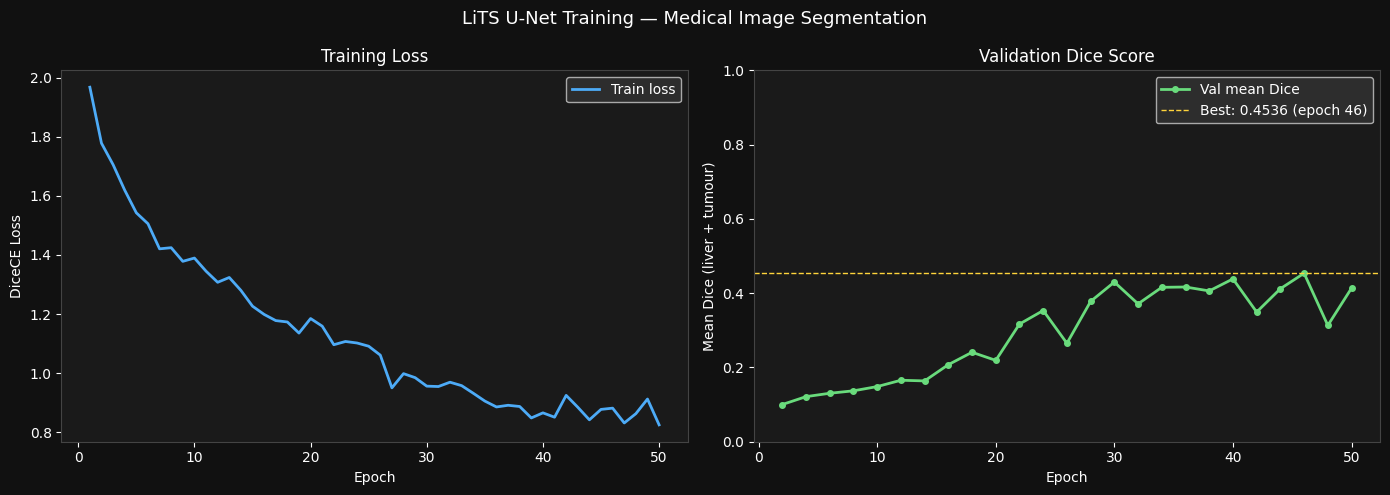

training_curves.png


In [20]:
#Plot training curves (run after training finishes)

import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#111111')

for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

# Training loss
ax1.plot(range(1, len(train_losses) + 1),
         train_losses, color='#4dabf7', linewidth=2, label='Train loss')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('DiceCE Loss')
ax1.legend(facecolor='#333333', labelcolor='white')

# Validation Dice
val_epochs = list(range(VAL_INTERVAL, MAX_EPOCHS + 1, VAL_INTERVAL))[:len(val_dice_scores)]
ax2.plot(val_epochs, val_dice_scores,
         color='#69db7c', linewidth=2, marker='o', markersize=4, label='Val mean Dice')
ax2.axhline(y=best_dice, color='#ffd43b', linestyle='--',
            linewidth=1, label=f'Best: {best_dice:.4f} (epoch {best_epoch})')
ax2.set_title('Validation Dice Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean Dice (liver + tumour)')
ax2.set_ylim(0, 1)
ax2.legend(facecolor='#333333', labelcolor='white')

plt.suptitle('LiTS U-Net Training — Medical Image Segmentation',
             color='white', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png',
            bbox_inches='tight', facecolor='#111111', dpi=150)
plt.show()
print("training_curves.png")

## Day 3 — Training Loop

**What happens each epoch:**
1. **Forward pass** — model predicts segmentation for each batch
2. **Loss computation** — DiceCELoss compares prediction vs ground truth
3. **Backward pass** — gradients flow back through the network
4. **Optimizer step** — weights updated to reduce loss
5. **Every 2 epochs** — evaluate on full validation volumes using
   sliding window inference, save best checkpoint

**What to expect:**
- Epochs 1-10:  Loss drops quickly, Dice rises fast from ~0.1 to ~0.5
- Epochs 10-40: Slower improvement, Dice reaches 0.6-0.7 for liver
- Epochs 40+:   Fine-tuning, tumour Dice slowly improves (harder task)
- Liver Dice typically reaches 0.85-0.92 on LiTS
- Tumour Dice typically reaches 0.45-0.65 (small, hard to segment)